# Project 2 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You can then choose from one of the three themes for part 2.

You will be working with a subset of the Cats and Dogs data set (and maybe a subset of the MNIST data set).

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke".

# Part 1

*Everyone should do this task.*

For the first part, use the provided Cats and Dogs data set.

Use at least 3 different classifiers and at least 2 feature selection methods.

For example, you can use filtering or wrappers in conjuction with any of the classifiers (using e.g. threshholds on the importance, t-tests/F-tests or CV-error with forward selection etc). I.e., for the filtering method you choose a test or scoring mechanism and use CV to determine the optimal threshold.

For the wrapper method you choose, e.g., forward selection or backward selection, CV is used when to stop adding features. Here, the scoring mechanism to decide which order to drop/add features can be based on drop/increase in predictive performance, importance metrics, etc.

The embedding methods we have talked about in class is lasso/elastic net which is used with multinomial/logistic regression. For the embedding methods, CV is used to choose the penalty parameter.

Note, you can also use a combination of techniques - perhaps you want to filter the features before you use wrappers or embedding methods?

Questions to answer

1. Using CV, determine how many features (pixels) you need for classification. Does the optimal number of features differ between the approaches?

2. Which pixels are selected? Does this differ between the approaches/classification methods? (Can you think of why?)

3. Repeat the above a few times - is the selection stable? (meaning the number of features needed and/or which pixels are chosen is roughly the same across multiple runs).



## Import packages

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree


## Load the data

In [4]:
PATHIM = "C://Users//wwide//MVE441//cnd_large//images.csv" 
PATHLB = "C://Users//wwide//MVE441//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


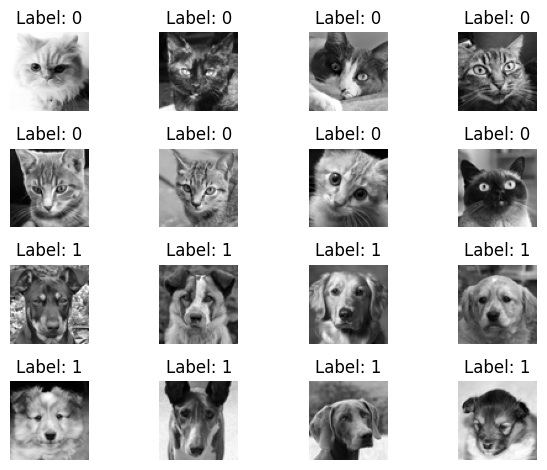

In [5]:
images = np.array(images)
labels = np.array(labels).ravel()

#Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 8

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(4, 4)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

## Train/test + 10 fold CV

In [6]:
X = images
y = labels

# Fixed train/test split
X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X, y, test_size=0.2,  stratify=y, shuffle=True)

# 10 folds CV
size_of_folds = len(X_train_full) // 10
X_folds = []
Y_folds = []

for i in range(10):
    X_folds.append(X_train_full[i*size_of_folds:size_of_folds*(i+1)])
    Y_folds.append(Y_train_full[i*size_of_folds:size_of_folds*(i+1)])
  
X_folds = np.array(X_folds)
Y_folds = np.array(Y_folds)

## Feature selection

### RandomForestClassifier

In [ ]:
# KÖR EJ
# Samla all träningsdata
X_train = np.concatenate(X_folds)
Y_train = np.concatenate(Y_folds)

# Definiera parametergrid
param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 20],
    "max_features": ["sqrt", 0.1],
    "min_samples_leaf": [1, 5]
}

# Skapa modell
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Grid search
rf_cv = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Träna
rf_cv.fit(X_train, Y_train)

# Resultat
print("Best params:", rf_cv.best_params_)
print("Best CV score:", rf_cv.best_score_)

# Hämta bästa modell
best_rf = rf_cv.best_estimator_

# Feature importance (valfritt men ofta användbart)
importances = best_rf.feature_importances_

# Sortera features efter vikt
indices = np.argsort(importances)[::-1]

print("\nTop 10 features:")
for i in range(min(10, len(importances))):
    print(f"Feature {indices[i]}: {importances[indices[i]]:.4f}")

In [7]:
importance_per_fold = []
train_folds_data = [] # Vi sparar (X_train, Y_train) här
val_folds_data = []   # Vi sparar (X_val, Y_val) här
selected_features_n_pxiels = []

for i in range(10):
    X_val = X_folds[i]
    Y_val = Y_folds[i]

    X_train_list = []
    Y_train_list = []
    for j in range(10):
        if j != i:
            X_train_list.append(X_folds[j])
            Y_train_list.append(Y_folds[j])
    
    X_train_cont = np.concatenate(X_train_list)
    Y_train_cont = np.concatenate(Y_train_list)

    train_folds_data.append((X_train_cont, Y_train_cont))
    val_folds_data.append((X_val, Y_val))
            
    # Select top k features
    rf_selector = RandomForestClassifier(n_jobs=-1, max_depth = None, max_features ='sqrt', min_samples_leaf= 1, n_estimators= 500)
    rf_selector.fit(X_train_cont, Y_train_cont)
    importances = rf_selector.feature_importances_
    sorted_index = np.argsort(importances)[::-1]
    importance_per_fold.append(sorted_index)

In [9]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Test different classifiers 
num_feature_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000] 
cart_scores_mean = []
rf_scores_mean = []
logreg_scores_mean = []
for k in (num_feature_list):
    print(f"Trial using {k} features:")
    accuracy_scores_rf = []
    accuracy_scores_cart = []
    accuracy_scores_log = []

    for i in range(10):
        X_train_current, Y_train_current = train_folds_data[i]
        X_val_current, Y_val_current = val_folds_data[i]
        
        top_features = importance_per_fold[i][:k]

        # Nu använder du de "current" variablerna
        X_train_selected = X_train_current[:, top_features]
        X_val_selected = X_val_current[:, top_features]

        # Random Forest
        rf_model = RandomForestClassifier(random_state=123)
        rf_model.fit(X_train_selected, Y_train_current) 

        # Predictions 
        rf_preds = rf_model.predict(X_val_selected) # same here, change to selected later
        accuracy_rf = accuracy_score(Y_val_current, rf_preds)
        accuracy_scores_rf.append(accuracy_rf)
        #print(f"Fold {i+1} - Random Forest Accuracy: {accuracy_rf:.4f}")

        # CART
        CART_model = DecisionTreeClassifier(random_state=123, max_depth=10, min_samples_split=15, min_samples_leaf=60, splitter="best", criterion="entropy")
        CART_model.fit(X_train_selected, Y_train_current) # change to selected later

        # Predictions 
        CART_preds = CART_model.predict(X_val_selected) # same here, change to selected later
        accuracy_CART = accuracy_score(Y_val_current, CART_preds)
        accuracy_scores_cart.append(accuracy_CART)
        #print(f"Fold {i+1} - CART Accuracy: {accuracy_CART:.4f}")

        # Logistic Regression
        log_model = LogisticRegression(random_state=123, max_iter=10000, penalty=None)
        log_model.fit(X_train_selected, Y_train_current)
        log_preds = log_model.predict(X_val_selected)
        accuracy_log = accuracy_score(Y_val_current, log_preds)
        accuracy_scores_log.append(accuracy_log)
        #print(f"Fold {i+1} - Logistic Regression Accuracy: {accuracy_log:.4f}")

    mean_rf = np.mean(accuracy_scores_rf)
    rf_scores_mean.append(mean_rf)
    print(f'Mean value of RandomForest for {k} features: {mean_rf}')

    mean_cart = np.mean(accuracy_scores_cart)
    cart_scores_mean.append(mean_cart)
    print(f'Mean value of CART for {k} features: {mean_cart}')

    mean_logreg = np.mean(accuracy_scores_log)
    logreg_scores_mean.append(mean_logreg)
    print(f'Mean value of Logistic Regression for {k} features: {mean_logreg}')

Trial using 100 features:
Mean value of RandomForest for 100 features: 0.802375
Mean value of CART for 100 features: 0.744125
Mean value of Logistic Regression for 100 features: 0.73475
Trial using 200 features:
Mean value of RandomForest for 200 features: 0.8241249999999999
Mean value of CART for 200 features: 0.745375
Mean value of Logistic Regression for 200 features: 0.74325
Trial using 300 features:
Mean value of RandomForest for 300 features: 0.8465
Mean value of CART for 300 features: 0.75775
Mean value of Logistic Regression for 300 features: 0.781
Trial using 400 features:
Mean value of RandomForest for 400 features: 0.8553750000000001
Mean value of CART for 400 features: 0.757
Mean value of Logistic Regression for 400 features: 0.78375
Trial using 500 features:
Mean value of RandomForest for 500 features: 0.8626250000000001
Mean value of CART for 500 features: 0.756375
Mean value of Logistic Regression for 500 features: 0.78625
Trial using 600 features:
Mean value of RandomFo

C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increas

Mean value of RandomForest for 900 features: 0.8724999999999999
Mean value of CART for 900 features: 0.750875
Mean value of Logistic Regression for 900 features: 0.782125
Trial using 1000 features:


C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increas

Mean value of RandomForest for 1000 features: 0.8716250000000001
Mean value of CART for 1000 features: 0.749375
Mean value of Logistic Regression for 1000 features: 0.778875


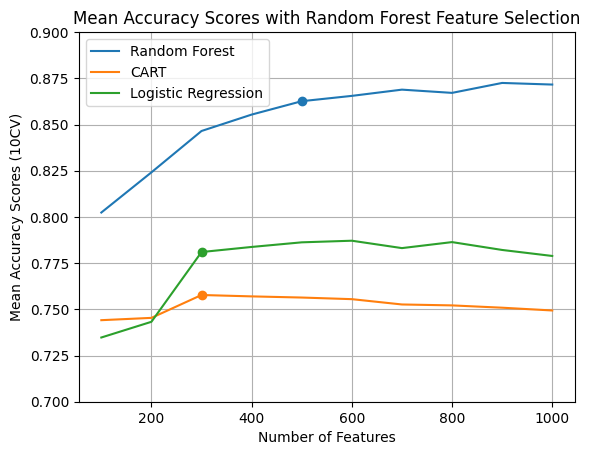

In [21]:

plt.plot(num_feature_list, rf_scores_mean, label ='Random Forest')
plt.plot(num_feature_list, cart_scores_mean, label = 'CART')
plt.plot(num_feature_list, logreg_scores_mean, label ='Logistic Regression')
plt.ylabel('Mean Accuracy Scores (10CV)')
plt.xlabel('Number of Features')
plt.title('Mean Accuracy Scores with Random Forest Feature Selection')
plt.ylim(0.7,0.9)
plt.legend()
plt.scatter(500, 0.8626)
plt.scatter(300, 0.7575)
plt.scatter(300, 0.781)
plt.grid()
#plt.plot(num_feature_list,cart_scores_mean)
plt.show()

In [ ]:
    # image_size = (64, 64)
    # image = np.zeros(image_size)

    # # Chosen features from feature selection
    # white_pixel_indices = top_features 

    # # The chosen features (pixels) as white the rest as black
    # for index in white_pixel_indices:
    #     row = index // image_size[1]
    #     col = index % image_size[1]
    #     image[row, col] = 1.0

    # plt.imshow(image, cmap='gray', vmin=0, vmax=1)
    # plt.axis('off')
    # plt.title(f"64x64 image with top {k} features as white pixels")
    # plt.show()

###  Lasso regression

In [22]:
X = images
y = labels

# Fixed train/test split
X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X, y, test_size=0.2,  stratify=y, shuffle=True)

X_mean = X_train_full.mean()
X_std = X_train_full.std()
X_scaled = (X_train_full-X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

# 10 folds CV
size_of_folds = len(X_scaled) // 10
X_folds = []
Y_folds = []

for i in range(10):
    X_folds.append(X_scaled[i*size_of_folds:size_of_folds*(i+1)])
    Y_folds.append(Y_train_full[i*size_of_folds:size_of_folds*(i+1)])
  
X_folds = np.array(X_folds)
Y_folds = np.array(Y_folds)

GridSearch to find the best parameter value of C

In [ ]:
# KÖR INTE
X_train = np.concatenate(X_folds)
Y_train = np.concatenate(Y_folds)

params = {"C":np.logspace(-4, 2, 100)}

lasso = LogisticRegression(l1_ratio=1.0, solver='liblinear', max_iter=10000)

lasso_cv=GridSearchCV(lasso, param_grid=params, n_jobs=-1)
lasso_cv.fit(X_train, Y_train)
print("Best Params (1/$\lambda$) {}".format(lasso_cv.best_params_))

Full run with Lasso regression using hyperparameters found using GridSearch.

In [23]:
importance_per_fold = []
train_folds_data = [] # Vi sparar (X_train, Y_train) här
val_folds_data = []   # Vi sparar (X_val, Y_val) här

for i in range(10):
    X_val = X_folds[i]
    Y_val = Y_folds[i]

    X_train_list = []
    Y_train_list = []
    for j in range(10):
        if j != i:
            X_train_list.append(X_folds[j])
            Y_train_list.append(Y_folds[j])
    
    X_train_cont = np.concatenate(X_train_list)
    Y_train_cont = np.concatenate(Y_train_list)

    train_folds_data.append((X_train_cont, Y_train_cont))
    val_folds_data.append((X_val, Y_val))
            
    # Select top k features
    lasso_selector = LogisticRegression(l1_ratio=1, solver='liblinear', C=0.06, max_iter=10000)
    lasso_selector.fit(X_train_cont, Y_train_cont)
    importances = np.abs(lasso_selector.coef_[0])
    sorted_index = np.argsort(importances)[::-1]
    importance_per_fold.append(sorted_index)

In [24]:
# Test different classifiers
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

num_feature_list = [100, 150, 200, 250, 300, 350, 400, 600, 800, 1000]
cart_scores_mean = []
rf_scores_mean = []
logreg_scores_mean = []
for k in (num_feature_list):
    print(f"Trial using {k} features:")
    accuracy_scores_rf = []
    accuracy_scores_cart = []
    accuracy_scores_log = []

    for i in range(10):
        X_train_current, Y_train_current = train_folds_data[i]
        X_val_current, Y_val_current = val_folds_data[i]
        
        top_features = importance_per_fold[i][:k]

        # Nu använder du de "current" variablerna
        X_train_selected = X_train_current[:, top_features]
        X_val_selected = X_val_current[:, top_features]

        # Random Forest
        rf_model = RandomForestClassifier(random_state=123)
        rf_model.fit(X_train_selected, Y_train_current) 

        # Predictions 
        rf_preds = rf_model.predict(X_val_selected) # same here, change to selected later
        accuracy_rf = accuracy_score(Y_val_current, rf_preds)
        accuracy_scores_rf.append(accuracy_rf)
        # print(f"Fold {i+1} - Random Forest Accuracy: {accuracy_rf:.4f}")

        # CART
        CART_model = DecisionTreeClassifier(random_state=123, max_depth=10, min_samples_split=15, min_samples_leaf=60, splitter="best", criterion="entropy")
        CART_model.fit(X_train_selected, Y_train_current) # change to selected later

        # Predictions 
        CART_preds = CART_model.predict(X_val_selected) # same here, change to selected later
        accuracy_CART = accuracy_score(Y_val_current, CART_preds)
        accuracy_scores_cart.append(accuracy_CART)
        # print(f"Fold {i+1} - CART Accuracy: {accuracy_CART:.4f}")

        # Logistic Regression
        log_model = LogisticRegression(random_state=123, max_iter=10000, penalty=None)
        log_model.fit(X_train_selected, Y_train_current)
        log_preds = log_model.predict(X_val_selected)
        accuracy_log = accuracy_score(Y_val_current, log_preds)
        accuracy_scores_log.append(accuracy_log)
        # print(f"Fold {i+1} - Logistic Regression Accuracy: {accuracy_log:.4f}")

    mean_rf = np.mean(accuracy_scores_rf)
    rf_scores_mean.append(mean_rf)
    print(f'Mean value of RandomForest for {k} features: {mean_rf}')

    mean_cart = np.mean(accuracy_scores_cart)
    cart_scores_mean.append(mean_cart)
    print(f'Mean value of CART for {k} features: {mean_cart}')

    mean_logreg = np.mean(accuracy_scores_log)
    logreg_scores_mean.append(mean_logreg)
    print(f'Mean value of Logistic Regression for {k} features: {mean_logreg}')

Trial using 100 features:
Mean value of RandomForest for 100 features: 0.858625
Mean value of CART for 100 features: 0.751
Mean value of Logistic Regression for 100 features: 0.8166249999999999
Trial using 150 features:
Mean value of RandomForest for 150 features: 0.8623749999999999
Mean value of CART for 150 features: 0.7457499999999999
Mean value of Logistic Regression for 150 features: 0.81525
Trial using 200 features:
Mean value of RandomForest for 200 features: 0.867125
Mean value of CART for 200 features: 0.745625
Mean value of Logistic Regression for 200 features: 0.813625
Trial using 250 features:
Mean value of RandomForest for 250 features: 0.866875
Mean value of CART for 250 features: 0.74775
Mean value of Logistic Regression for 250 features: 0.81425
Trial using 300 features:
Mean value of RandomForest for 300 features: 0.868625
Mean value of CART for 300 features: 0.75025
Mean value of Logistic Regression for 300 features: 0.8135
Trial using 350 features:
Mean value of Rand

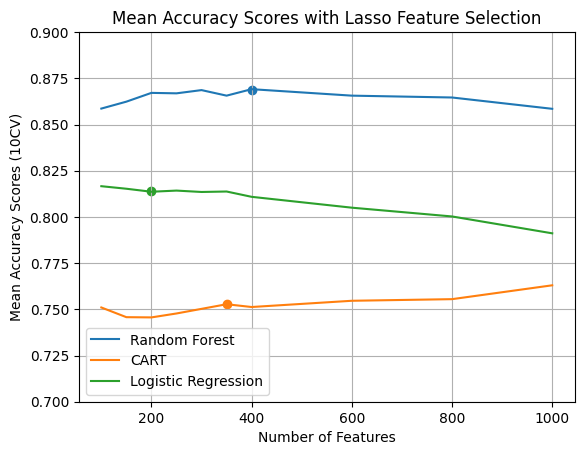

In [33]:
# Visualisation of accuracy for k selected features for each classifier

plt.plot(num_feature_list, rf_scores_mean, label ='Random Forest')
plt.plot(num_feature_list, cart_scores_mean, label = 'CART')
plt.plot(num_feature_list, logreg_scores_mean, label ='Logistic Regression')
plt.ylabel('Mean Accuracy Scores (10CV)')
plt.xlabel('Number of Features')
plt.title('Mean Accuracy Scores with Lasso Feature Selection')
plt.legend()
plt.ylim(0.70, 0.90)
plt.scatter(400, 0.8686)
plt.scatter(350, 0.7528)
plt.scatter(200, 0.814)
plt.grid()
plt.show()

## Classification using the selected features

### Feature thresholds for each classifier

In [34]:
k_Lasso = [400, 350, 200]

X_train_Lasso = X_scaled.copy()
Y_train_Lasso = Y_train_full.copy()
X_test_Lasso = X_test_scaled.copy()

# Select top 400 features
lasso_selector_400 = LogisticRegression(l1_ratio=1, solver='liblinear', C=0.06, max_iter=10000)
lasso_selector_400.fit(X_train_Lasso, Y_train_Lasso)
coefficients_Lasso_400 = lasso_selector_400.coef_[0]
sorted_index_Lasso_400 = np.argsort(np.abs(coefficients_Lasso_400))[::-1]
top_features_Lasso_400 = sorted_index_Lasso_400[:k_Lasso[0]] # Change k for more / less features

# Keep only selected features
X_train_selected_Lasso_400 = X_train_Lasso[:, top_features_Lasso_400]
X_test_Lasso_400 = X_test_Lasso[:, top_features_Lasso_400]

# Select top 200 features
lasso_selector_350 = LogisticRegression(l1_ratio=1, solver='liblinear', C=0.06, max_iter=10000)
lasso_selector_350.fit(X_train_Lasso, Y_train_Lasso)
coefficients_Lasso_350 = lasso_selector_350.coef_[0]
sorted_index_Lasso_350 = np.argsort(np.abs(coefficients_Lasso_350))[::-1]
top_features_Lasso_350 = sorted_index_Lasso_350[:k_Lasso[1]] # Change k for more / less features

# Keep only selected features
X_train_selected_Lasso_350 = X_train_Lasso[:, top_features_Lasso_350]
X_test_Lasso_350 = X_test_Lasso[:, top_features_Lasso_350]

# Select top 600 features
lasso_selector_200 = LogisticRegression(l1_ratio=1, solver='liblinear', C=0.06, max_iter=10000)
lasso_selector_200.fit(X_train_Lasso, Y_train_Lasso)
coefficients_Lasso_200 = lasso_selector_200.coef_[0]
sorted_index_Lasso_200 = np.argsort(np.abs(coefficients_Lasso_200))[::-1]
top_features_Lasso_200 = sorted_index_Lasso_200[:k_Lasso[2]] # Change k for more / less features

# Keep only selected features
X_train_selected_Lasso_200 = X_train_Lasso[:, top_features_Lasso_200]
X_test_Lasso_200 = X_test_Lasso[:, top_features_Lasso_200]

In [35]:
k_Forest = [500, 300, 300]

# RandomForest features
selected_features_n_pixels = []
X_train_Forest = X_train_full.copy()
Y_train_Forest = Y_train_full.copy()
X_test_Forest = X_test.copy()

# Select top 600 features
rf_selector_500 = RandomForestClassifier(n_jobs=-1, max_depth=None, max_features='sqrt', min_samples_leaf=1, n_estimators=500)
rf_selector_500.fit(X_train_Forest, Y_train_Forest)
importances_Forest_500 = rf_selector_500.feature_importances_
sorted_index_Forest_500 = np.argsort(importances_Forest_500)[::-1]
top_features_Forest_500 = sorted_index_Forest_500[:k_Forest[0]]

X_train_selected_Forest_500 = X_train_Forest[:, top_features_Forest_500]
X_test_Forest_500 = X_test_Forest[:, top_features_Forest_500]

# Select top 300 features
rf_selector_300 = RandomForestClassifier(n_jobs=-1, max_depth=None, max_features='sqrt', min_samples_leaf=1, n_estimators=500)
rf_selector_300.fit(X_train_Forest, Y_train_Forest)
importances_Forest_300 = rf_selector_300.feature_importances_
sorted_index_Forest_300 = np.argsort(importances_Forest_300)[::-1]
top_features_Forest_300 = sorted_index_Forest_300[:k_Forest[1]]

X_train_selected_Forest_300 = X_train_Forest[:, top_features_Forest_300]
X_test_Forest_300 = X_test_Forest[:, top_features_Forest_300]

# Select top 100 features
# rf_selector_100 = RandomForestClassifier(n_jobs=-1, max_depth=None, max_features='sqrt', min_samples_leaf=1, n_estimators=500)
# rf_selector_100.fit(X_train_Forest, Y_train_Forest)
# importances_Forest_100 = rf_selector_100.feature_importances_
# sorted_index_Forest_100 = np.argsort(importances_Forest_100)[::-1]
# top_features_Forest_100 = sorted_index_Forest_100[:k_Forest[2]]

# X_train_selected_Forest_100 = X_train_Forest[:, top_features_Forest_100]
# X_test_Forest_100 = X_test_Forest[:, top_features_Forest_100]

### Classification method 1 RandomForest

In [36]:
lasso_forest_model = RandomForestClassifier(n_jobs=-1, max_depth = None, max_features ='sqrt', min_samples_leaf= 1, n_estimators= 500)
lasso_forest_model.fit(X_train_selected_Lasso_400, Y_train_Lasso)

# Predictions 
lasso_preds = lasso_forest_model.predict(X_test_Lasso_400)
accuracy_lasso_forest = accuracy_score(Y_test, lasso_preds)

print(f"Random Forest Accuracy with Lasso-selected features: {accuracy_lasso_forest:.4f}")

forest_forest_model = RandomForestClassifier(n_jobs=-1, max_depth = None, max_features ='sqrt', min_samples_leaf= 1, n_estimators= 500)
forest_forest_model.fit(X_train_selected_Forest_500, Y_train_Forest)

# Predictions
forest_preds = forest_forest_model.predict(X_test_Forest_500)
accuracy_forest_forest = accuracy_score(Y_test, forest_preds)
print(f"Random Forest Accuracy with Forest-selected features: {accuracy_forest_forest:.4f}")

Random Forest Accuracy with Lasso-selected features: 0.8725
Random Forest Accuracy with Forest-selected features: 0.8620


### Classification method 2 logistic regresion

In [37]:
lasso_regression_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000)
lasso_regression_model.fit(X_train_selected_Lasso_350, Y_train_Lasso)

# Predictions
lasso_preds = lasso_regression_model.predict(X_test_Lasso_350)
accuracy_lasso_regression = accuracy_score(Y_test, lasso_preds)
print(f"Logistic Regression Accuracy with Lasso-selected features: {accuracy_lasso_regression:.4f}")

forest_regression_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000) # Add hyperparameters (GridSearch??)
forest_regression_model.fit(X_train_selected_Forest_300, Y_train_Forest)

# Predictions
forest_preds = forest_regression_model.predict(X_test_Forest_300)
accuracy_forest_regression = accuracy_score(Y_test, forest_preds)

print(f"Logistic Regression Accuracy with Random Forest-selected features: {accuracy_forest_regression:.4f}")

Logistic Regression Accuracy with Lasso-selected features: 0.8130
Logistic Regression Accuracy with Random Forest-selected features: 0.7825


### Classification method 3 CART

In [38]:
# CART
lasso_cart_model = DecisionTreeClassifier(random_state=123, max_depth=10, min_samples_split=15, min_samples_leaf=60, splitter="best", criterion="entropy") # Add hyperparameters (GridSearch??)
lasso_cart_model.fit(X_train_selected_Lasso_200, Y_train_Lasso)

# Predictions
lasso_cart_preds = lasso_cart_model.predict(X_test_Lasso_200)
accuracy_lasso_cart = accuracy_score(Y_test, lasso_cart_preds)
print(f"CART Accuracy with Lasso-selected features: {accuracy_lasso_cart:.4f}")

forest_cart_model = DecisionTreeClassifier(random_state=123, max_depth=10, min_samples_split=15, min_samples_leaf=60, splitter="best", criterion="entropy") # Add hyperparameters (GridSearch??)
forest_cart_model.fit(X_train_selected_Forest_300, Y_train_Forest)

# Predictions
forest_cart_preds = forest_cart_model.predict(X_test_Forest_300)
accuracy_forest_cart = accuracy_score(Y_test, forest_cart_preds)

print(f"CART Accuracy with Random Forest-selected features: {accuracy_forest_cart:.4f}")



CART Accuracy with Lasso-selected features: 0.7545
CART Accuracy with Random Forest-selected features: 0.7715


## Part 2 - Themes
Choose ***one*** theme of the three and perform ***all*** tasks as described in this theme.

### Theme 1 - Correlated noise features
Use the Cats and Dogs data set. 

Add (independent) Gaussian noise to a subset of the features. Increase the percentage of the features. 
How is classification accuracy affected for the different methods?

Now, do the same but with correlated Gaussian noise. 
How do the different methods handle correlated noise features? 
At what noise level do the methods break down? 

### Theme 2 - Image flip
Use the Cats and Dogs data set. 

Flip half of the images (half of the cats and half of the dogs) upside down. 
Perform the same steps as in Part 1. 

How is feature importance affected by the flipping?

### Theme 3 - Heterogeneous classes
Use the MNIST data set. 

Create heterogeneous classes by flipping half of the images in a class. 
1. First, flip images in class 0.
2. Then, flip images in class 4 (and revert the changes from the previous step).
3. Lastly, flip images in one of class 2, 5, 6 or 9 (and revert the changes from the previous step).

Perform the same steps as in Part 1 for the three sets. 

Present confusion matrices and other appropriate plots. What happened? 

In [ ]:
PATHIM = "C://Users//wwide//MVE441//cnd_large//images.csv" 
PATHLB = "C://Users//wwide//MVE441//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

In [ ]:
images = np.array(images)
labels = np.array(labels).ravel()

#Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

In [ ]:
# images 50% of class 1 flipped and 50% of class 0 flipped
target_class_0 = np.where(labels == 0)[0]
target_class_1 = np.where(labels == 1)[0]

num_flip = len(target_class_0) // 2 # Half of the data

flip_indices_0 = np.random.choice(target_class_0, size=num_flip, replace=False)
flip_indices_1 = np.random.choice(target_class_1, size=num_flip, replace=False)

X = images
y = labels

X[flip_indices_0] = np.fliplr(X[flip_indices_0]) # Flip class 0
X[flip_indices_1] = np.fliplr(X[flip_indices_1]) # Flip class 1

In [ ]:
# Select one index that was flipped
sample_idx = flip_indices_0[0] 

# Plotting to verify
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# The image as it exists in X now (already flipped in your code)
img_after = X[sample_idx].reshape(64, 64)
ax.imshow(img_after, cmap="gray")
ax.set_title("Example of Flipped Image in Dataset")

plt.show()

In [ ]:
# Fixed train/test split
X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X, y, test_size=0.2,  stratify=y, shuffle=True)

# 10 folds CV
size_of_folds = len(X_train_full) // 10
X_folds = []
Y_folds = []

for i in range(10):
    X_folds.append(X_train_full[i*size_of_folds:size_of_folds*(i+1)])
    Y_folds.append(Y_train_full[i*size_of_folds:size_of_folds*(i+1)])
  
X_folds = np.array(X_folds)
Y_folds = np.array(Y_folds)